<a href="https://colab.research.google.com/github/KeerthanaSistla/Sem6DeepLearning/blob/main/DeepLearningSem6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction

Features of Deep Learning
*   Requires More amount of data
*   DL deals with non linear-data
*   Images, videos, audio and text
*   Complex model (hard to interpret)
*   Requires Graphical and Tenser Processing Units
*   Takes large computation
*   Automatic feature extractuion

PyTourch
*   Implimented  using LUA

TensorFlow
*   Implimented using C++, CUDA or Python

Keras
*   Implimented using Python

#Basic Coding

In [ ]:
import tensorflow as tf


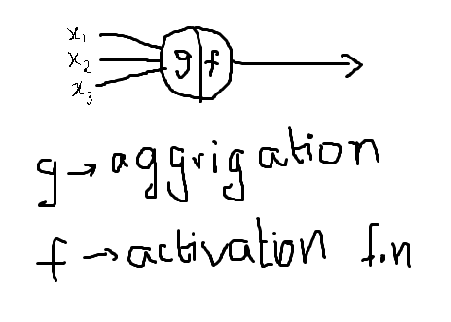

**g (aggrigation)** adds i.e., x1 + x2 + x3

**f (activation)** checks with condition
*   Step f.n, Sigmoid f.n, etc.
*   Fired if output is tangable

**Weights**
*   Priority of each input
*   g = x1w1 + x2w2 + x3w3

**Bias**
*   Adds non-linearity
*   Acts as a decision boundry

#Week 2

In [3]:
import numpy as np

def step(x):
  return 1 if x >= 0 else 0

class Perceptron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias

  def predict(self, inputs):
              z = np.dot(self.weights, inputs)+self.bias
              return step(z)

#AND Operation
weights = np.array([1, 1])
bias = -1.5

and_gate = Perceptron(weights, bias)

print("AND Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", and_gate.predict(np.array(x)))

#OR Operation
weights = np.array([1, 1])
bias = -0.5

or_gate = Perceptron(weights, bias)

print("OR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", or_gate.predict(np.array(x)))

AND Gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1
OR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


In [9]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)
        output = step(np.dot(self.w_out, [h1, h2]) + self.b_out)
        return output

xor = XOR_network()

print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor.predict(np.array(x)))

XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


In [10]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)
        return step(np.dot(self.w_out, [h1, h2]) + self.b_out)

class XNOR_network(XOR_network):
    def predict(self, x):
        return 1 - super().predict(x)

xnor = XNOR_network()

print("XNOR Gate")
for x in [(0,0),(0,1),(1,0),(1,1)]:
    print(x, "->", xnor.predict(np.array(x)))

XNOR Gate
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [11]:
#Harsh Threshold
import numpy as np

def step(x):
  return 1 if x >= 0 else 0

class Neuron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias
  def feedforward(self, inputs):
    total = np.dot(self.weights, inputs) + self.bias
    return step(total)

weights = np.array([0, 1])
b_1 = -3.1
b_2 = 2
b_3 = -3.0

n = Neuron(weights, b_1)
n_2 = Neuron(weights, b_2)
n_3 = Neuron(weights,b_3)

x = np.array([2, 3])

print("with bias -3.1:",n.feedforward(x))
print("\nwith bias -3.0:",n_3.feedforward(x))
print("\nwith bias 2:",n_2.feedforward(x))

with bias -3.1: 0

with bias -3.0: 1

with bias 2: 1


In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("movies.csv")

X = data[['f1', 'f2', 'f3', 'f4']].values
y = data['label'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

learning_rate = 0.01
epochs = 50
weights = np.zeros(X.shape[1])
bias = 0.0

def step_function(z):
    return 1 if z >= 0 else 0

for epoch in range(epochs):
    total_errors = 0

    indices = np.random.permutation(len(X))

    for i in indices:
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)

        error = y[i] - y_pred

        if error != 0:
            weights += learning_rate * error * X[i]
            bias += learning_rate * error
            total_errors += 1

    print(
        f"Epoch {epoch+1:02d} | "
        f"Errors: {total_errors} | "
        f"Weights: {weights.round(3)} | "
        f"Bias: {round(bias, 3)}"
    )

    if total_errors == 0:
        print("\nConverged")
        break

print("\nFinal Weights:", weights)
print("Final Bias:", bias)

Epoch 01 | Errors: 4 | Weights: [0.    0.    0.    0.028] | Bias: 0.0
Epoch 02 | Errors: 2 | Weights: [ 0.     0.    -0.02   0.032] | Bias: 0.0
Epoch 03 | Errors: 2 | Weights: [ 0.     0.    -0.     0.048] | Bias: 0.0
Epoch 04 | Errors: 1 | Weights: [ 0.01  -0.01  -0.008  0.047] | Bias: 0.01
Epoch 05 | Errors: 0 | Weights: [ 0.01  -0.01  -0.008  0.047] | Bias: 0.01

Converged

Final Weights: [ 0.01       -0.01       -0.00816497  0.04699912]
Final Bias: 0.01
